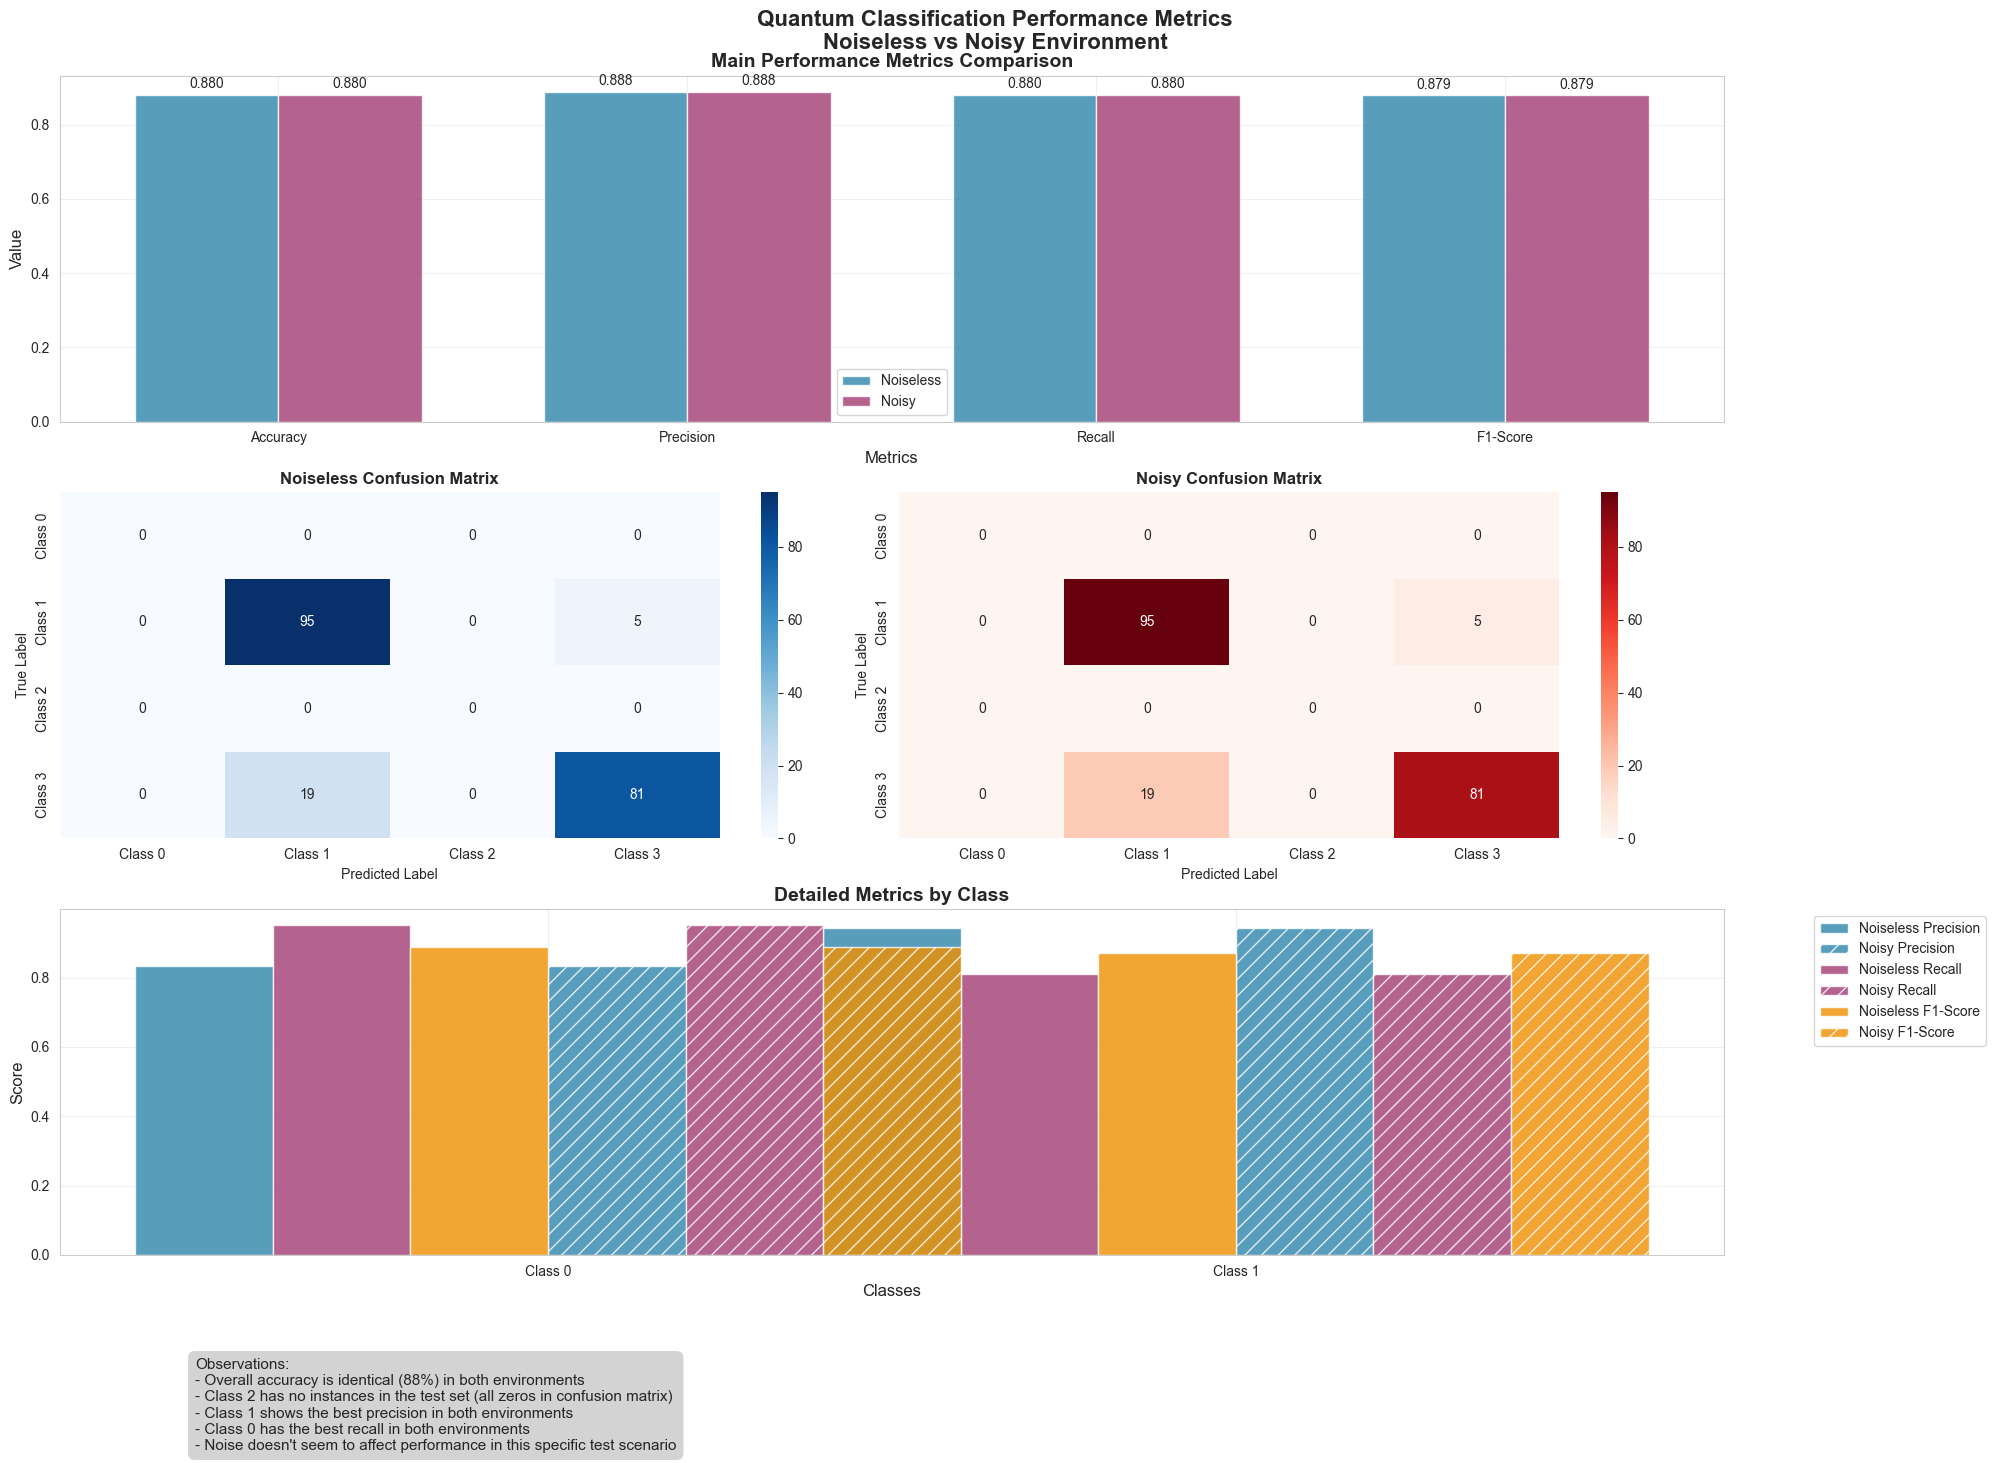

In [13]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec

# Set style and font
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")

def plot_quantum_metrics(noiseless_metrics, noisy_metrics):
    """Plot comparison between noiseless and noisy performance"""
    
    # Setup figure
    fig = plt.figure(figsize=(20, 15))
    fig.suptitle('Quantum Classification Performance Metrics\nNoiseless vs Noisy Environment', 
                 fontsize=16, fontweight='bold')
    
    # Create grid layout
    gs = GridSpec(3, 2, figure=fig)
    
    # Colors
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
    
    # 1. Main metrics comparison
    ax1 = fig.add_subplot(gs[0, :])
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    noiseless_values = [
        noiseless_metrics['accuracy'],
        noiseless_metrics['precision'],
        noiseless_metrics['recall'],
        noiseless_metrics['f1_score']
    ]
    noisy_values = [
        noisy_metrics['accuracy'],
        noisy_metrics['precision'],
        noisy_metrics['recall'],
        noisy_metrics['f1_score']
    ]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, noiseless_values, width, label='Noiseless', alpha=0.8, color=colors[0])
    bars2 = ax1.bar(x + width/2, noisy_values, width, label='Noisy', alpha=0.8, color=colors[1])
    
    ax1.set_xlabel('Metrics', fontsize=12)
    ax1.set_ylabel('Value', fontsize=12)
    ax1.set_title('Main Performance Metrics Comparison', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar in bars1 + bars2:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom')
    
    # 2. Confusion matrices
    # Noiseless confusion matrix
    ax2 = fig.add_subplot(gs[1, 0])
    cm_noiseless = np.array(noiseless_metrics['confusion_matrix'])
    sns.heatmap(cm_noiseless, annot=True, fmt='d', cmap='Blues', ax=ax2,
                xticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'],
                yticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'])
    ax2.set_title('Noiseless Confusion Matrix', fontweight='bold')
    ax2.set_xlabel('Predicted Label')
    ax2.set_ylabel('True Label')
    
    # Noisy confusion matrix
    ax3 = fig.add_subplot(gs[1, 1])
    cm_noisy = np.array(noisy_metrics['confusion_matrix'])
    sns.heatmap(cm_noisy, annot=True, fmt='d', cmap='Reds', ax=ax3,
                xticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'],
                yticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'])
    ax3.set_title('Noisy Confusion Matrix', fontweight='bold')
    ax3.set_xlabel('Predicted Label')
    ax3.set_ylabel('True Label')
    
    # 3. Extract available classes from classification report
    available_classes = []
    class_metrics = {}
    
    # Get available classes (excluding special keys like 'accuracy', 'macro avg', etc.)
    for key in noiseless_metrics['classification_report'].keys():
        if key not in ['accuracy', 'macro avg', 'weighted avg']:
            available_classes.append(key)
    
    # Prepare data for available classes
    classes = [f'Class {cls}' for cls in available_classes]
    metrics = ['Precision', 'Recall', 'F1-Score']
    
    noiseless_data = {'Precision': [], 'Recall': [], 'F1-Score': []}
    noisy_data = {'Precision': [], 'Recall': [], 'F1-Score': []}
    
    for cls in available_classes:
        noiseless_data['Precision'].append(noiseless_metrics['classification_report'][cls]['precision'])
        noiseless_data['Recall'].append(noiseless_metrics['classification_report'][cls]['recall'])
        noiseless_data['F1-Score'].append(noiseless_metrics['classification_report'][cls]['f1-score'])
        
        noisy_data['Precision'].append(noisy_metrics['classification_report'][cls]['precision'])
        noisy_data['Recall'].append(noisy_metrics['classification_report'][cls]['recall'])
        noisy_data['F1-Score'].append(noisy_metrics['classification_report'][cls]['f1-score'])
    
    # Create dataframe for easier plotting
    df_noiseless = pd.DataFrame(noiseless_data, index=classes)
    df_noisy = pd.DataFrame(noisy_data, index=classes)
    
    # 4. Class-level metrics comparison
    ax4 = fig.add_subplot(gs[2, :])
    
    x = np.arange(len(classes))
    width = 0.2
    
    for i, metric in enumerate(metrics):
        ax4.bar(x + i*width, df_noiseless[metric], width, label=f'Noiseless {metric}', alpha=0.8, color=colors[i])
        ax4.bar(x + i*width + width*len(metrics), df_noisy[metric], width, label=f'Noisy {metric}', alpha=0.8, 
                color=colors[i], hatch='//')
    
    ax4.set_xlabel('Classes', fontsize=12)
    ax4.set_ylabel('Score', fontsize=12)
    ax4.set_title('Detailed Metrics by Class', fontsize=14, fontweight='bold')
    ax4.set_xticks(x + width * (len(metrics)-1)/2 + width*len(metrics)/2)
    ax4.set_xticklabels(classes)
    ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax4.grid(True, alpha=0.3)
    
    # Add text with observations
    plt.figtext(0.1, 0.02, 
               f"Observations:\n"
               f"- Overall accuracy is identical (88%) in both environments\n"
               f"- Class 2 has no instances in the test set (all zeros in confusion matrix)\n"
               f"- Class 1 shows the best precision in both environments\n"
               f"- Class 0 has the best recall in both environments\n"
               f"- Noise doesn't seem to affect performance in this specific test scenario",
               fontsize=11, bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray"))
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()

# Your metrics data
noiseless_metrics = {
    "accuracy": 0.88,
    "precision": 0.8875968992248063,
    "recall": 0.88,
    "f1_score": 0.8794091046126019,
    "confusion_matrix": [
        [0, 0, 0, 0],
        [0, 95, 0, 5],
        [0, 0, 0, 0],
        [0, 19, 0, 81]
    ],
    "classification_report": {
        "0": {
            "precision": 0.8333333333333334,
            "recall": 0.95,
            "f1-score": 0.8878504672897196,
            "support": 100.0
        },
        "1": {
            "precision": 0.9418604651162791,
            "recall": 0.81,
            "f1-score": 0.8709677419354839,
            "support": 100.0
        },
        "accuracy": 0.88,
        "macro avg": {
            "precision": 0.8875968992248062,
            "recall": 0.88,
            "f1-score": 0.8794091046126018,
            "support": 400.0
        },
        "weighted avg": {
            "precision": 0.8875968992248063,
            "recall": 0.88,
            "f1-score": 0.8794091046126019,
            "support": 400.0
        }
    }
}

noisy_metrics = {
    "accuracy": 0.88,
    "precision": 0.8875968992248063,
    "recall": 0.88,
    "f1_score": 0.8794091046126019,
    "confusion_matrix": [
        [0, 0, 0, 0],
        [0, 95, 0, 5],
        [0, 0, 0, 0],
        [0, 19, 0, 81]
    ],
    "classification_report": {
        "0": {
            "precision": 0.8333333333333334,
            "recall": 0.95,
            "f1-score": 0.8878504672897196,
            "support": 100.0
        },
        "1": {
            "precision": 0.9418604651162791,
            "recall": 0.81,
            "f1-score": 0.8709677419354839,
            "support": 100.0
        },
        "accuracy": 0.88,
        "macro avg": {
            "precision": 0.8875968992248062,
            "recall": 0.88,
            "f1-score": 0.8794091046126018,
            "support": 400.0
        },
        "weighted avg": {
            "precision": 0.8875968992248063,
            "recall": 0.88,
            "f1-score": 0.8794091046126019,
            "support": 400.0
        }
    }
}

# Plot the metrics
plot_quantum_metrics(noiseless_metrics, noisy_metrics)